<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/U2_Temperature_Analysis_2026_R2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Electrical columns:
['Timestamp', 'Active_power(MW)', 'Reactive_power(Mvar)', 'UNIT Voltage_AB(kV)', 'UNIT Voltage_BC(kV)', 'UNIT Voltage_CA(kV)', 'UNIT CURRENT PHASE A', 'UNIT CURRENT PHASE B', 'UNIT CURRENT PHASE C', 'FIELD CURRENT', 'FIELD VOLTAGE']

Temperature columns:
['Timestamp', 'STATOR WINDING PHASE U2 TEMP', 'STATOR WINDING PHASE U164 TEMP', 'GENERATOR COOLING WATER INLET TEMP', 'UPPER BEARING OIL COOLER WARM WATER', 'LOWER BEARING OIL COOLER WARM WATER', 'UPPER GUIDE BEARING PAD TEMP', 'LOWER GUIDE BEARING PAD TEMP', 'COLD AIR TEMP', 'HOT AIR TEMP', 'GENERATOR COOLING WATER OUTLET TEMP']

Merged shape: (980, 21)

Rows before steady filter: 980
Rows after steady filter : 655


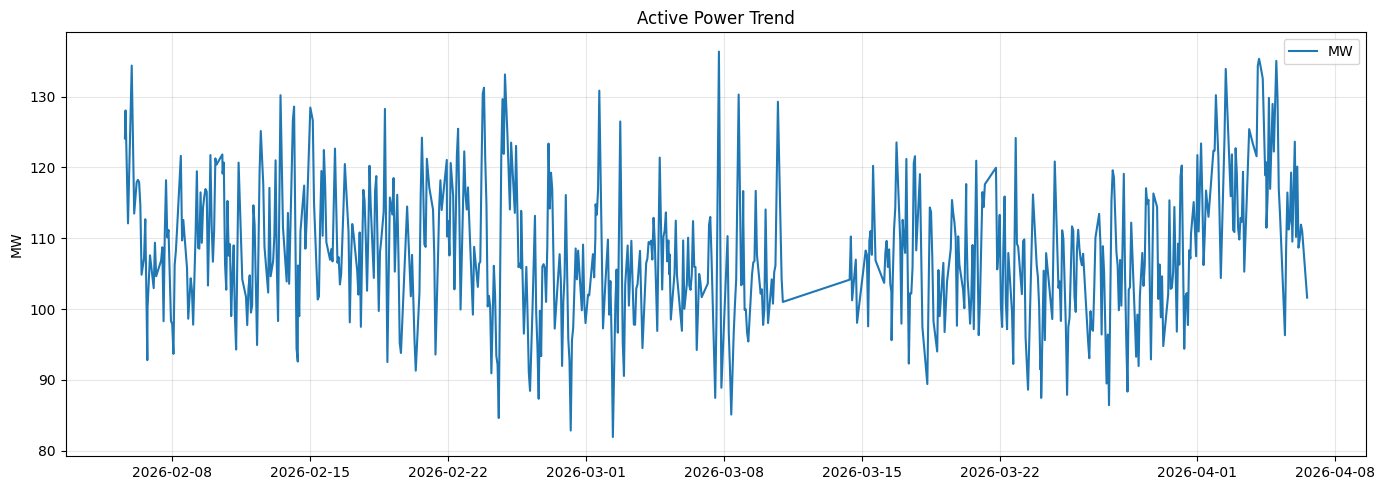

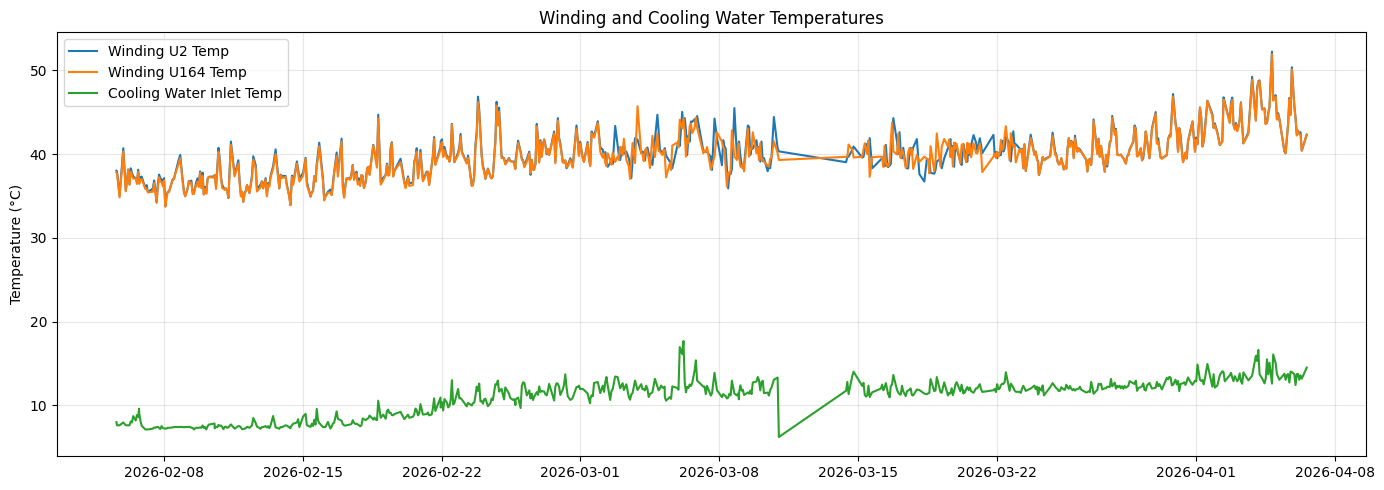

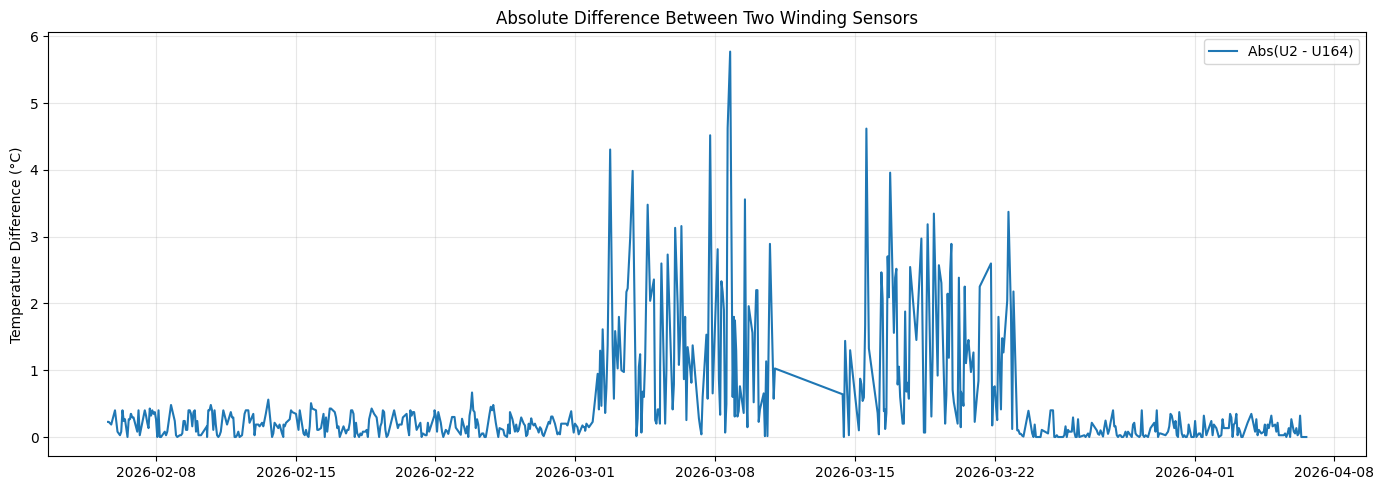

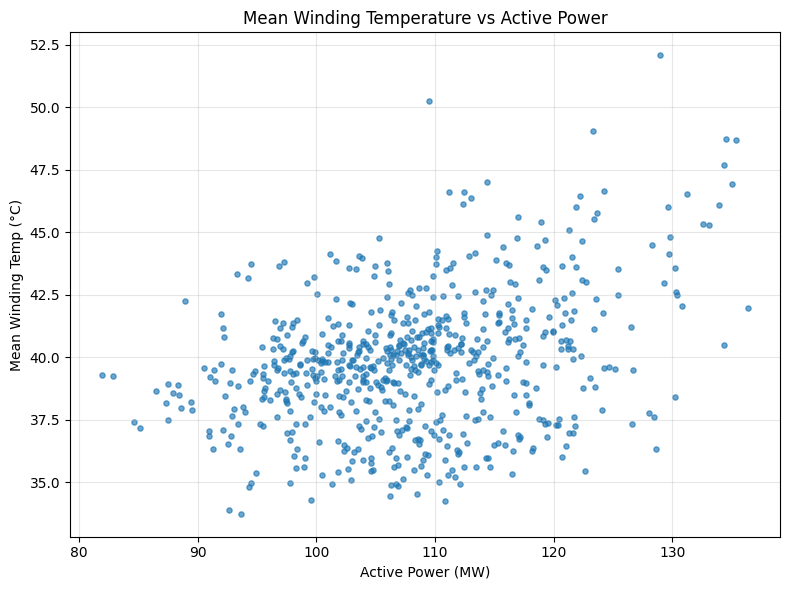

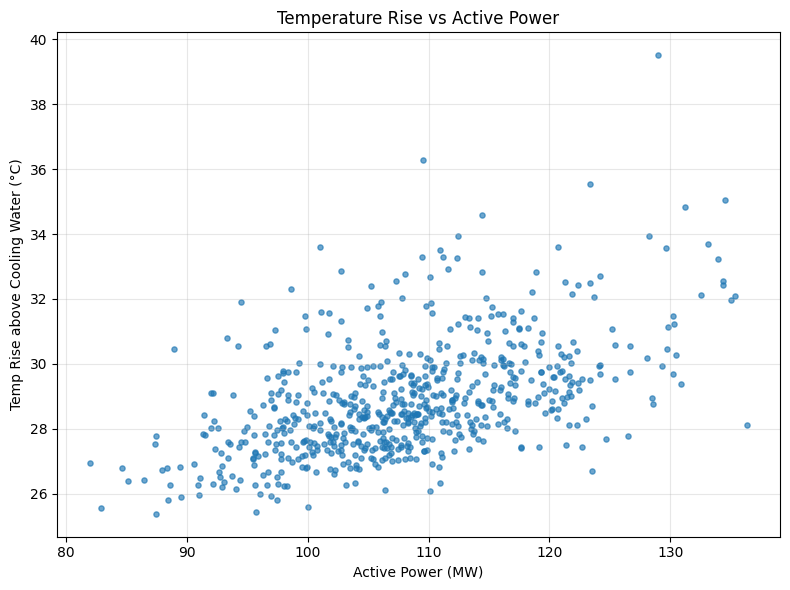

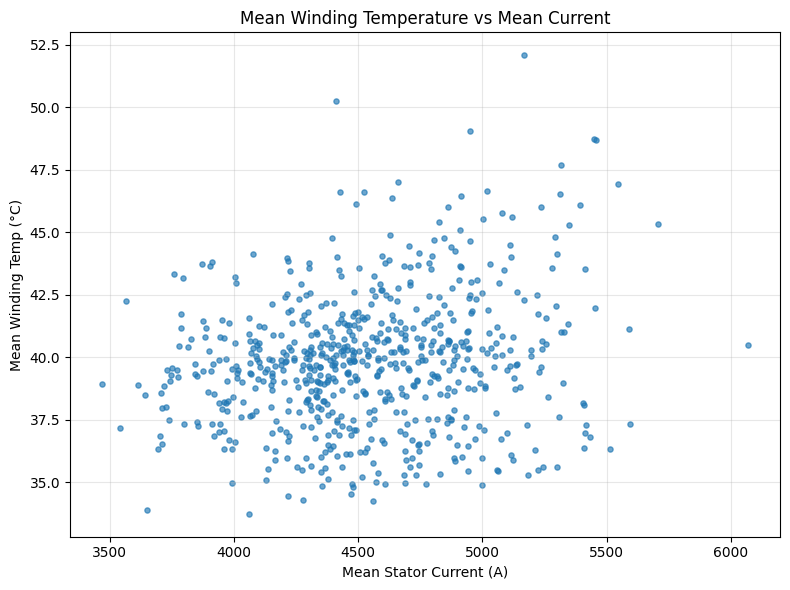

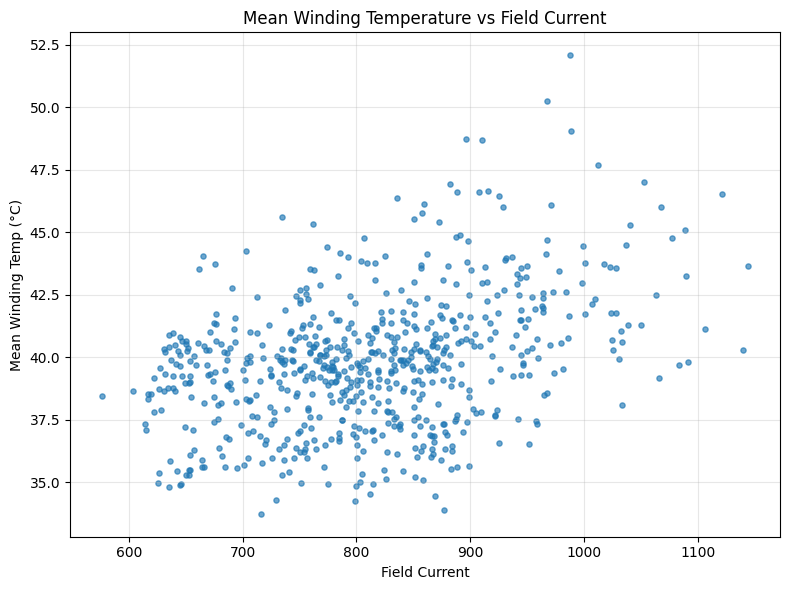

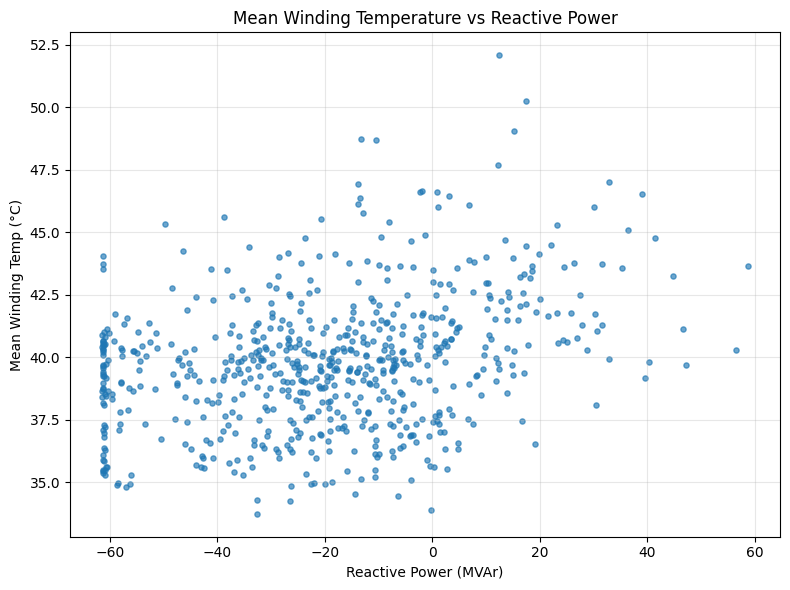

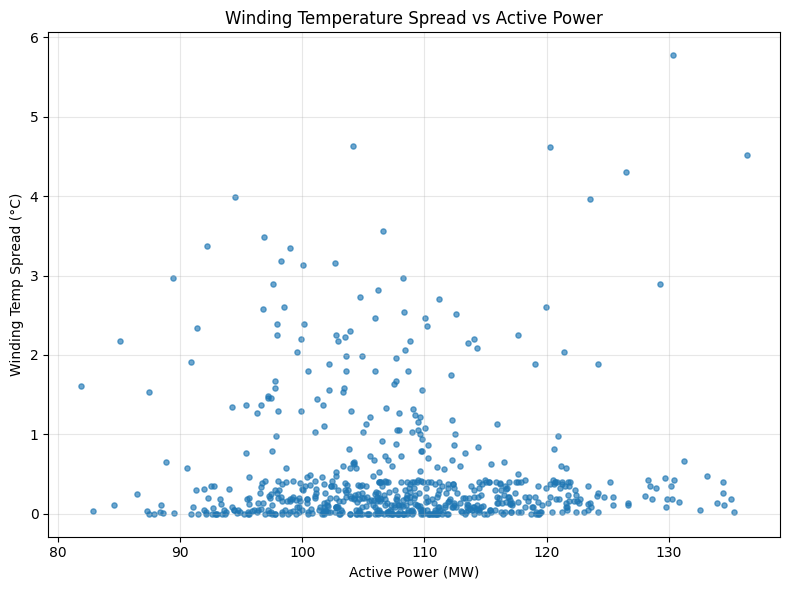

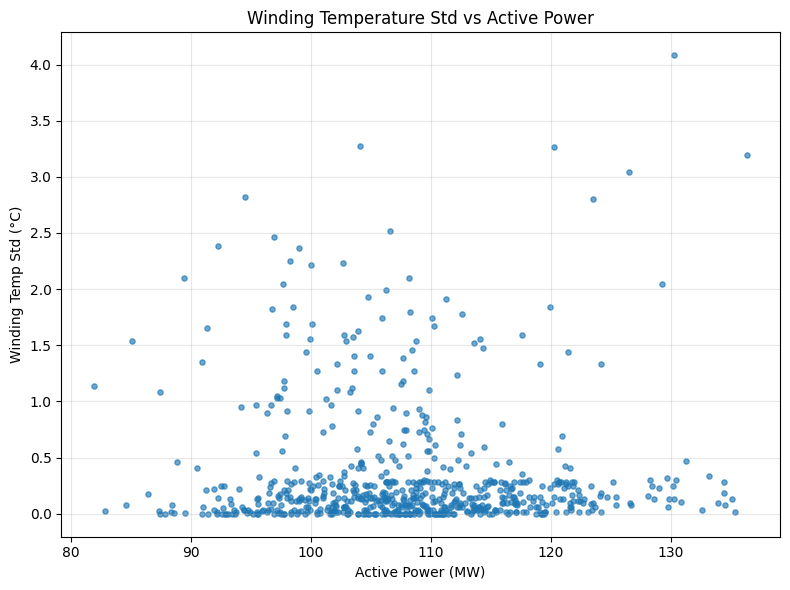

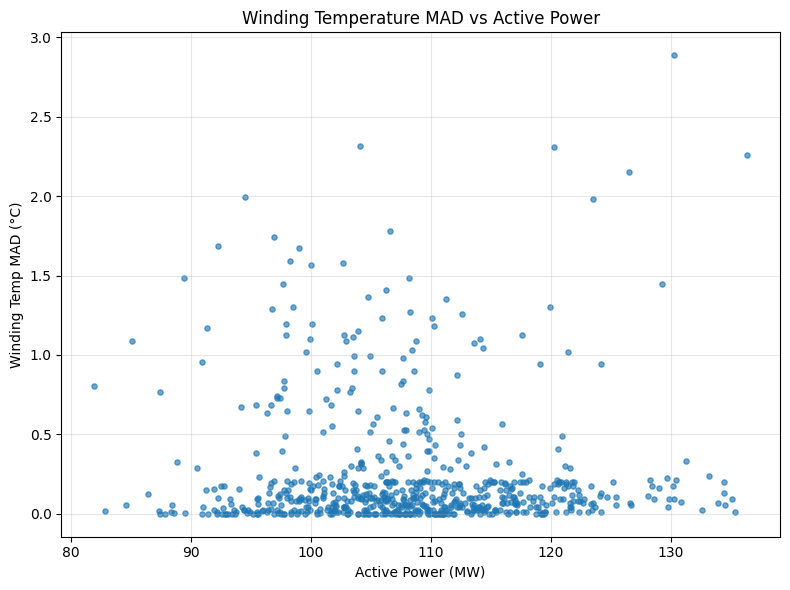

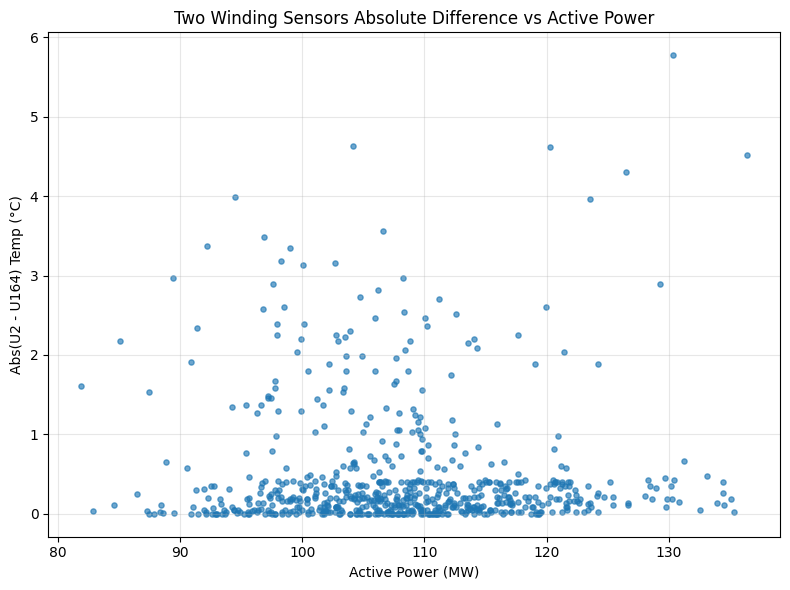

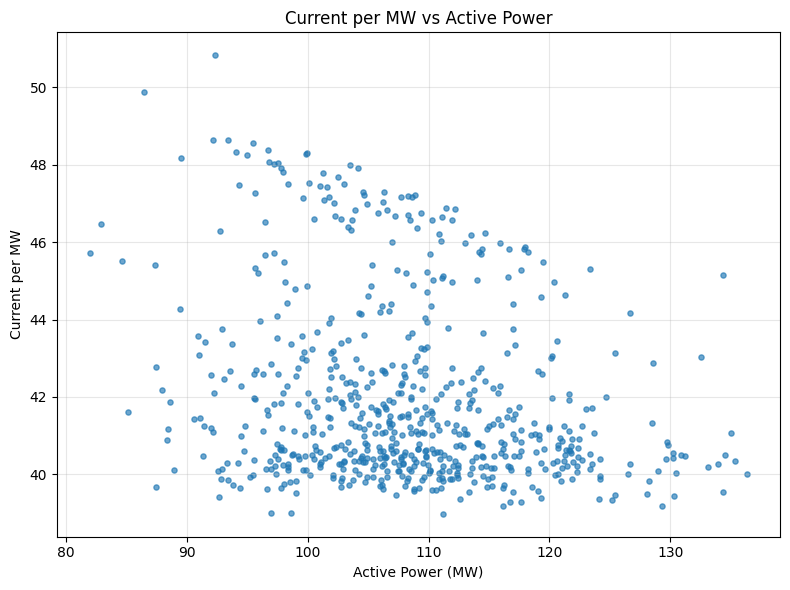

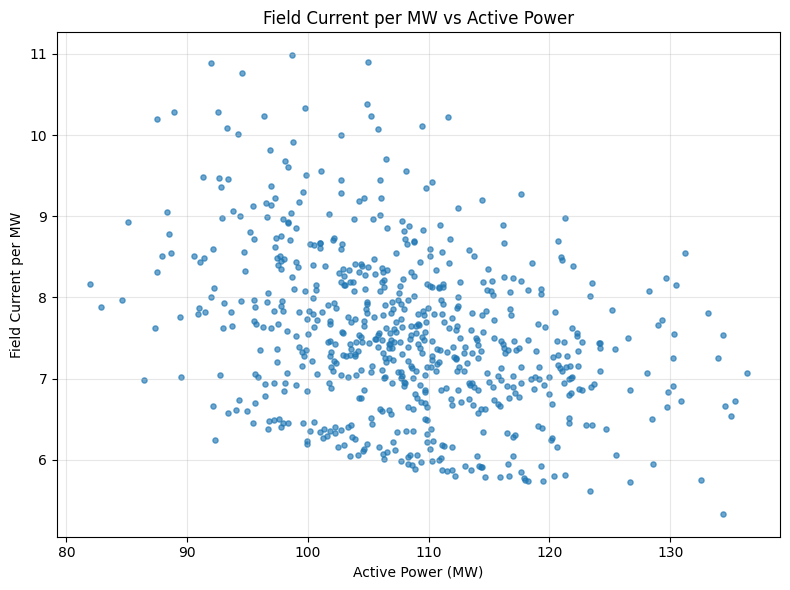

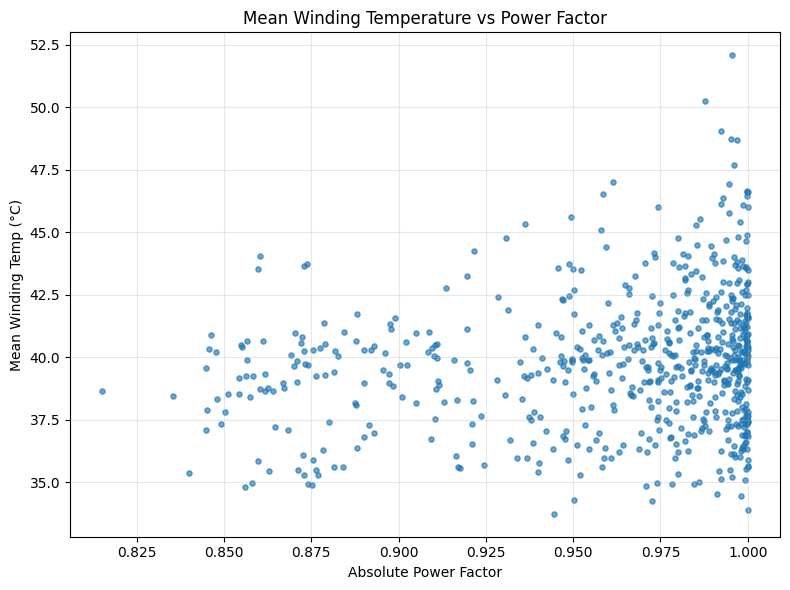

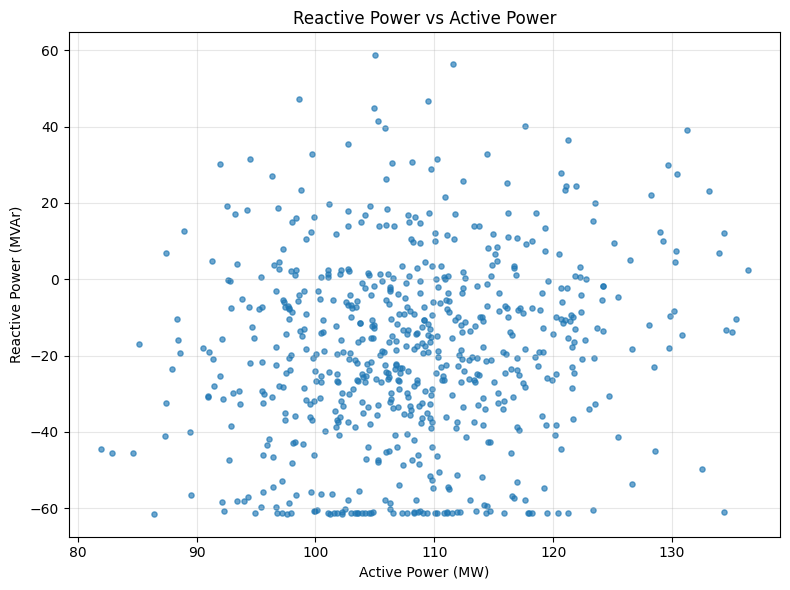

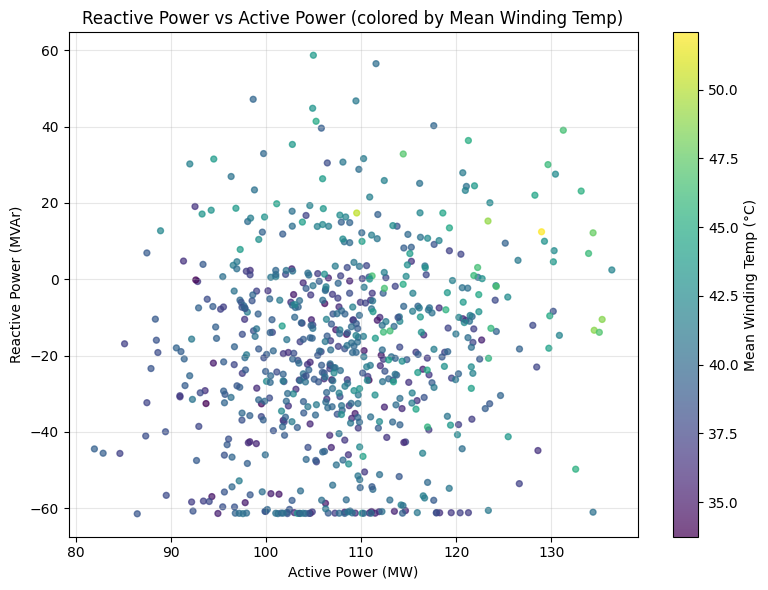

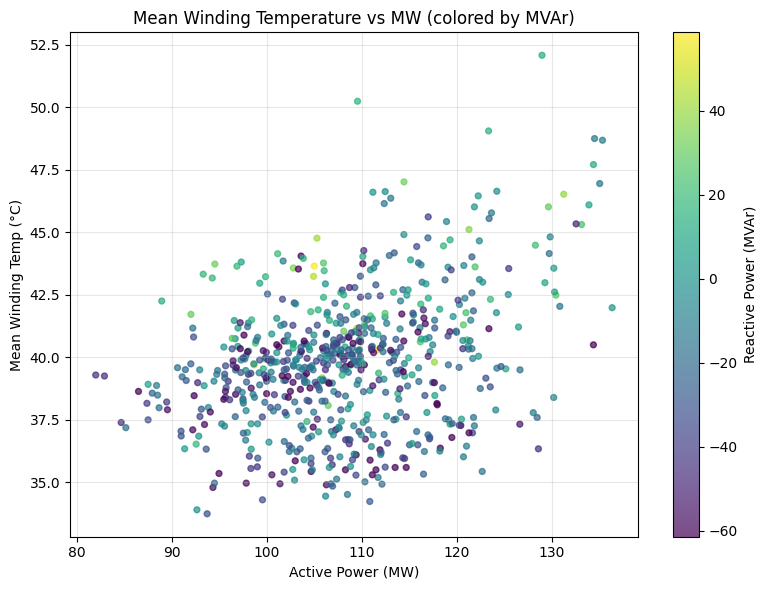

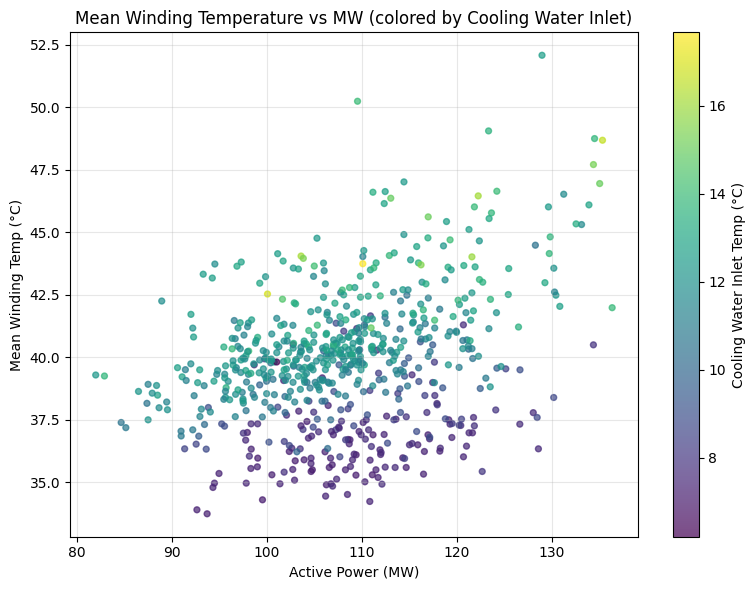

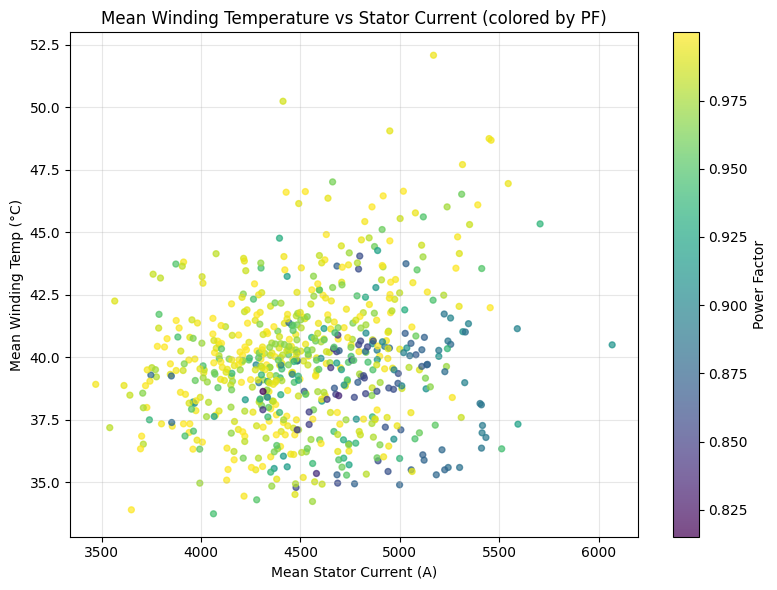

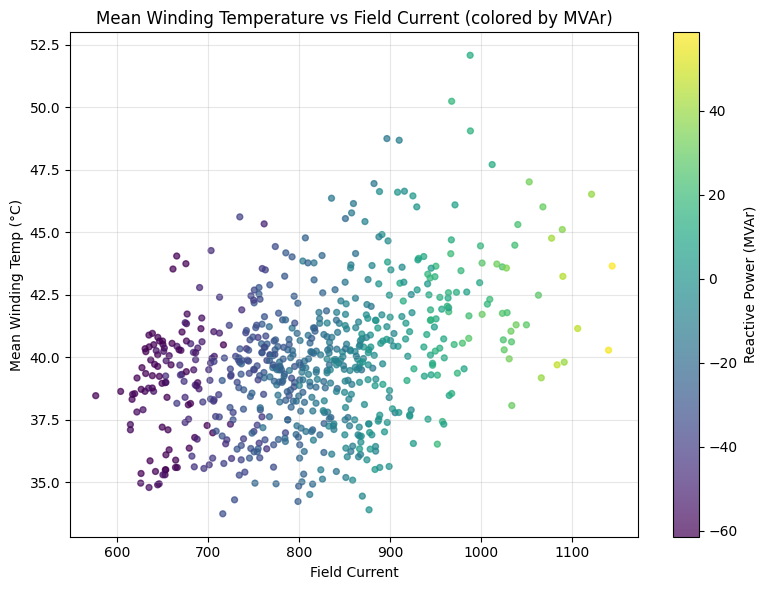

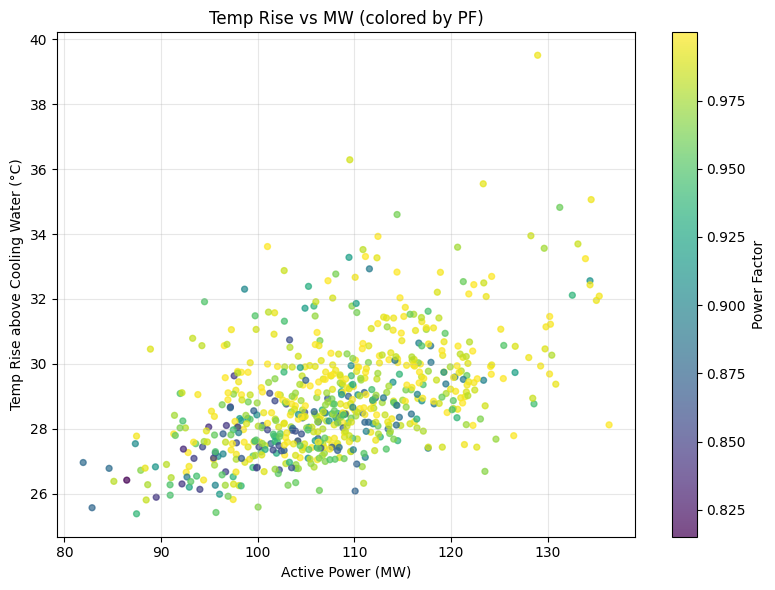

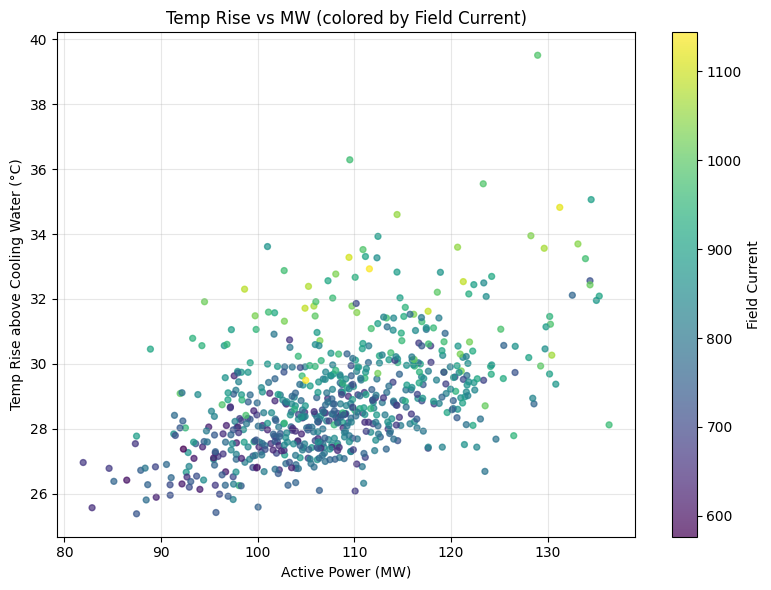

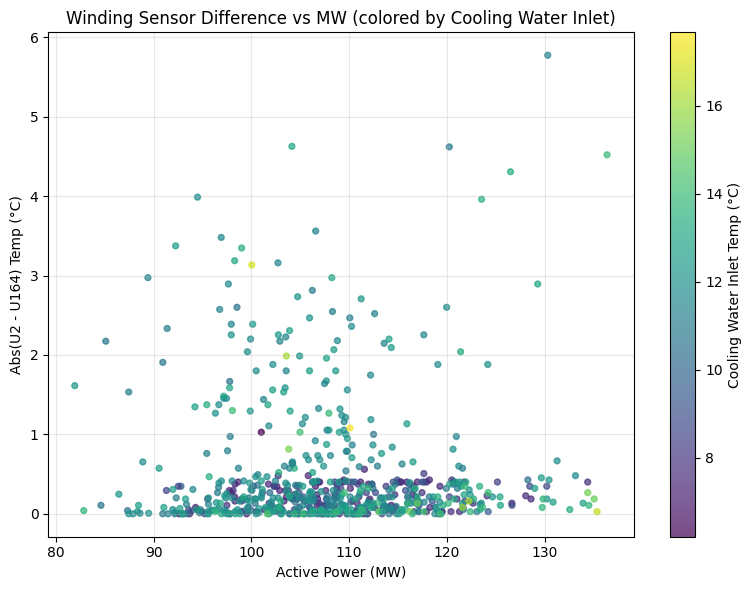

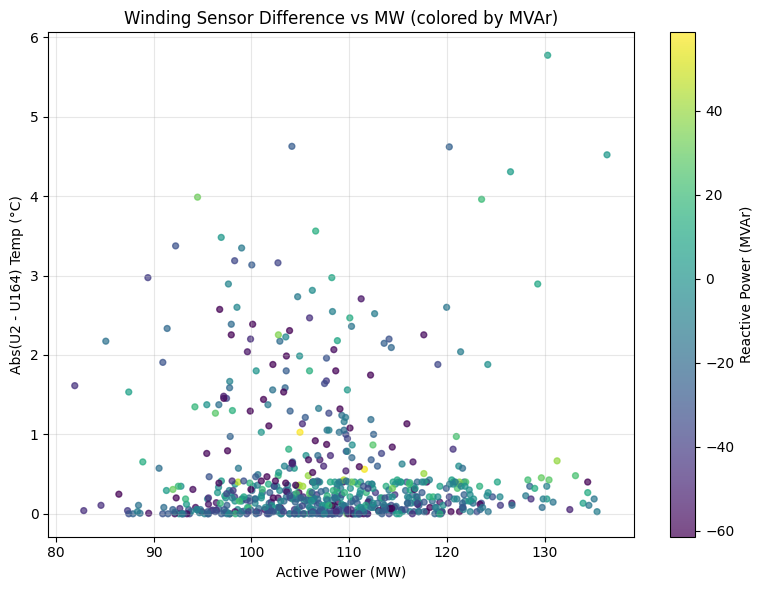


Temperature model performance:
R2  = 0.8001
MAE = 0.8863 °C


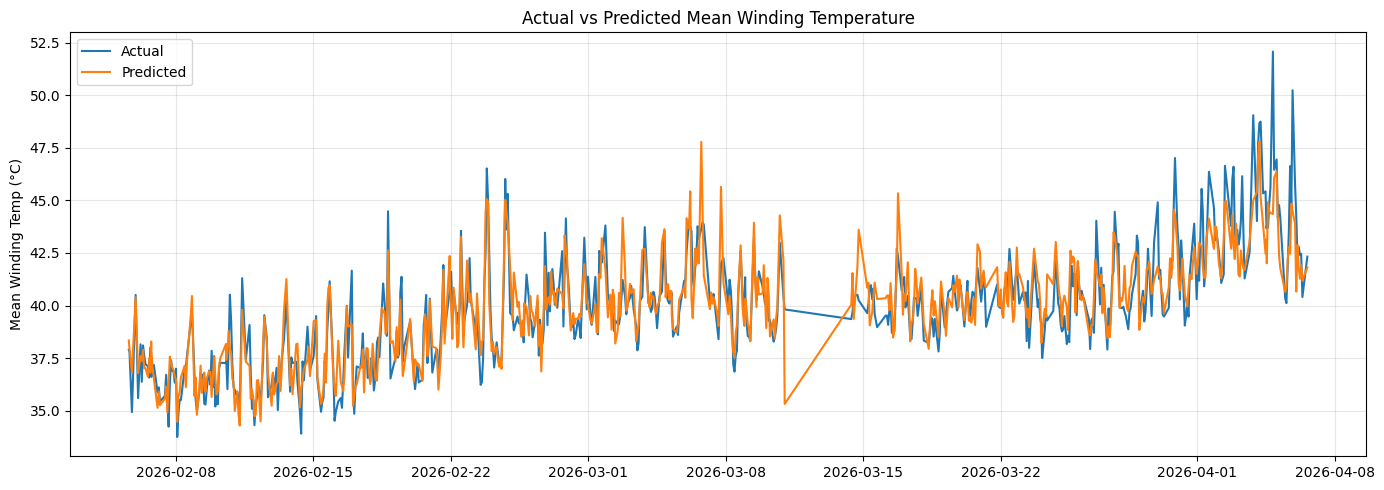

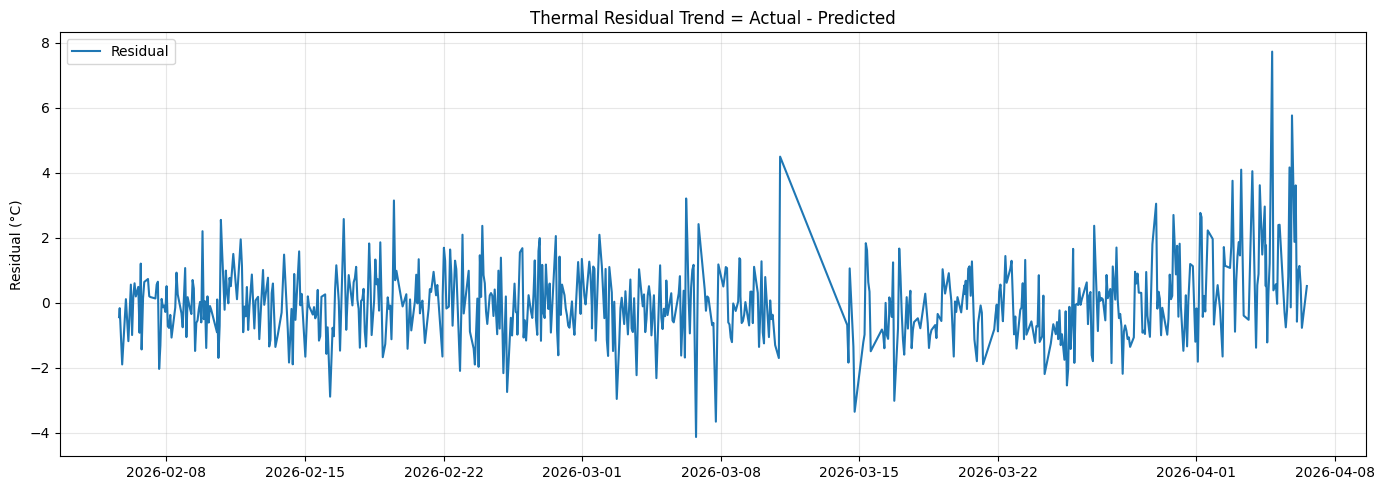


Residual alarm threshold (95% abs): 2.228 °C
Residual alarm events: 33


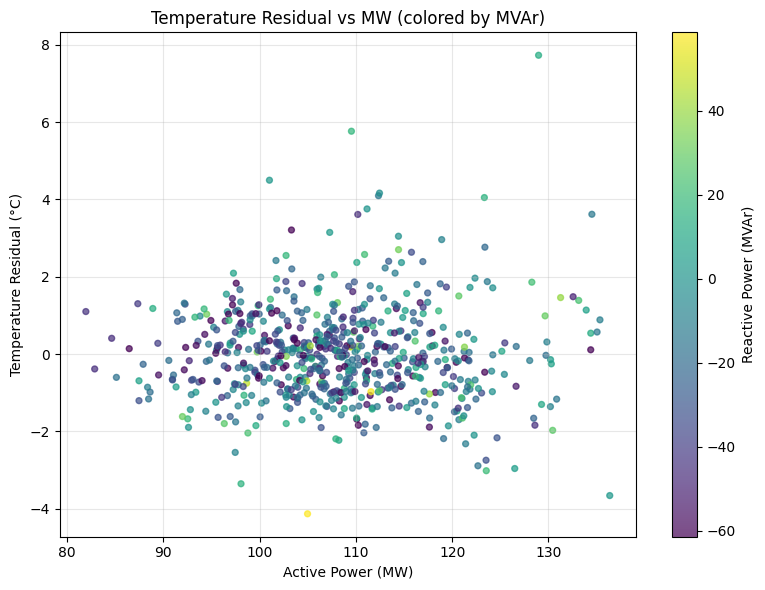

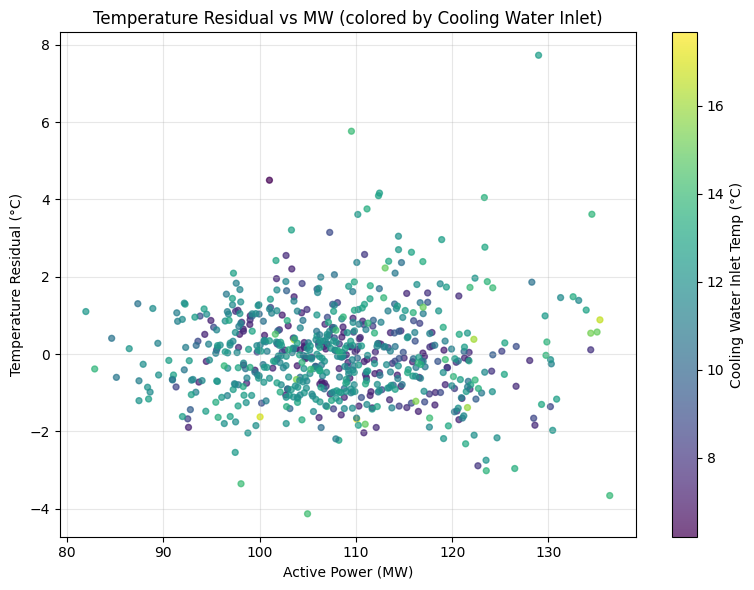

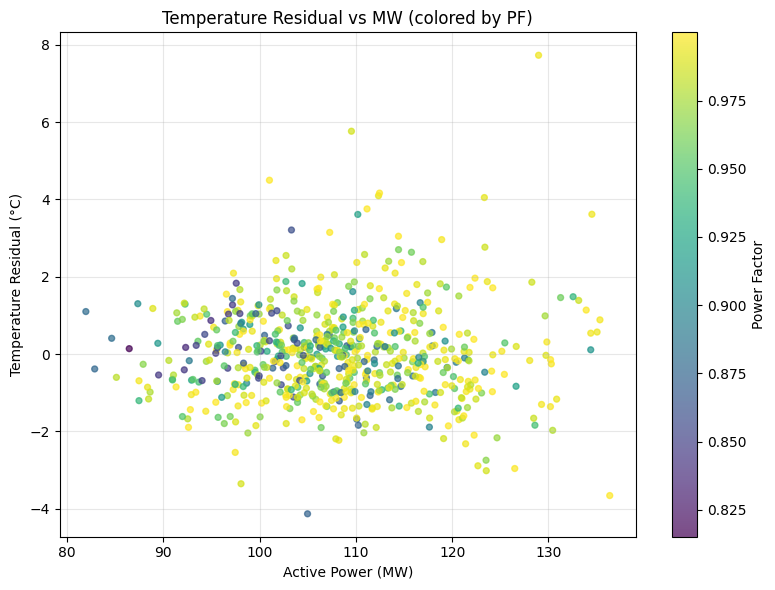

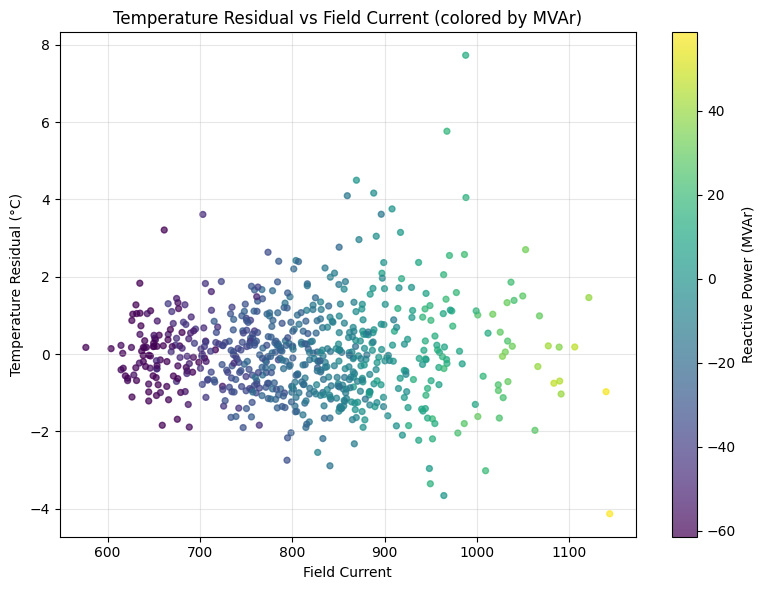


===== QUICK RESULTS =====
Date range: 2026-02-05 14:45:00 to 2026-04-06 14:20:00
Average MW: 108.14
Average MVAr: -19.51
Average PF: 0.9619
Average winding temp: 39.8 °C
Max winding temp: 52.25 °C
Average temp rise: 28.91 °C
Max temp rise: 39.51 °C
Average temp spread: 0.499 °C
Max temp spread: 5.773 °C
Average temp std: 0.353 °C
Average temp MAD: 0.249 °C
Average U2-U164 abs diff: 0.499 °C
Max U2-U164 abs diff: 5.773 °C
Average current unbalance (std): 2.88 %
Max current unbalance (std): 4.13 %
Average current unbalance (fast): 5.24 %
Max current unbalance (fast): 7.84 %

Files saved in folder: /content/generator_analysis_outputs

Done.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# =========================================================
# 1. FILE PATHS
# =========================================================
electrical_file = r"u2_electrical_data_6_4_2026_R2.csv"
temp_file       = r"u2_winding_temp_6_4_2026_R2.csv"

output_dir = Path("generator_analysis_outputs")
output_dir.mkdir(exist_ok=True)

# =========================================================
# 2. READ FILES
# =========================================================
elec = pd.read_csv(electrical_file, encoding="utf-16", sep="\t")
temp = pd.read_csv(temp_file, encoding="utf-16", sep="\t")

elec.columns = elec.columns.str.strip()
temp.columns = temp.columns.str.strip()

print("Electrical columns:")
print(elec.columns.tolist())
print("\nTemperature columns:")
print(temp.columns.tolist())

# =========================================================
# 3. PARSE TIMESTAMP
# =========================================================
elec["Timestamp"] = pd.to_datetime(elec["Timestamp"], errors="coerce")
temp["Timestamp"] = pd.to_datetime(temp["Timestamp"], errors="coerce")

elec = elec.dropna(subset=["Timestamp"]).copy()
temp = temp.dropna(subset=["Timestamp"]).copy()

elec = elec.sort_values("Timestamp").reset_index(drop=True)
temp = temp.sort_values("Timestamp").reset_index(drop=True)

# =========================================================
# 4. MERGE DATASETS
# =========================================================
df = pd.merge_asof(
    elec,
    temp,
    on="Timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("10min")
)

print("\nMerged shape:", df.shape)

# =========================================================
# 5. RENAME COLUMNS
# =========================================================
rename_map = {
    "Active_power(MW)": "MW",
    "Reactive_power(Mvar)": "MVAr",
    "UNIT Voltage_AB(kV)": "V_AB_kV",
    "UNIT Voltage_BC(kV)": "V_BC_kV",
    "UNIT Voltage_CA(kV)": "V_CA_kV",
    "UNIT CURRENT PHASE A": "I_A",
    "UNIT CURRENT PHASE B": "I_B",
    "UNIT CURRENT PHASE C": "I_C",
    "FIELD CURRENT": "Field_Current",
    "FIELD VOLTAGE": "Field_Voltage",

    "STATOR WINDING PHASE U2 TEMP": "Winding_U2_Temp",
    "STATOR WINDING PHASE U164 TEMP": "Winding_U164_Temp",

    "GENERATOR COOLING WATER INLET TEMP": "Cooling_Water_Inlet_Temp",
    "GENERATOR COOLING WATER OUTLET TEMP": "Cooling_Water_Outlet_Temp",
    "UPPER BEARING OIL COOLER WARM WATER": "Upper_Bearing_Warm_Water",
    "LOWER BEARING OIL COOLER WARM WATER": "Lower_Bearing_Warm_Water",
    "COLD AIR TEMP": "Cold_Air_Temp",
    "HOT AIR TEMP": "Hot_Air_Temp",
}
df = df.rename(columns=rename_map)

# =========================================================
# 6. CHECK REQUIRED COLUMNS
# =========================================================
required_cols = [
    "Timestamp", "MW", "MVAr",
    "I_A", "I_B", "I_C",
    "V_AB_kV", "V_BC_kV", "V_CA_kV",
    "Field_Current", "Field_Voltage",
    "Winding_U2_Temp", "Winding_U164_Temp",
    "Cooling_Water_Inlet_Temp"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# =========================================================
# 7. BASIC CLEANING
# =========================================================
numeric_cols = [c for c in df.columns if c != "Timestamp"]
for c in numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=[
    "MW", "MVAr",
    "I_A", "I_B", "I_C",
    "V_AB_kV", "V_BC_kV", "V_CA_kV",
    "Field_Current",
    "Winding_U2_Temp", "Winding_U164_Temp",
    "Cooling_Water_Inlet_Temp"
]).copy()

# =========================================================
# 8. WINDING SENSOR LIST
# =========================================================
winding_temp_cols = [
    "Winding_U2_Temp",
    "Winding_U164_Temp"
]

# =========================================================
# 9. DERIVED ELECTRICAL FEATURES
# =========================================================
df["V_mean_kV"] = df[["V_AB_kV", "V_BC_kV", "V_CA_kV"]].mean(axis=1)
df["I_mean"] = df[["I_A", "I_B", "I_C"]].mean(axis=1)

# Standard current unbalance
df["I_imbalance_std_pct"] = np.where(
    df["I_mean"] != 0,
    np.maximum.reduce([
        (df["I_A"] - df["I_mean"]).abs(),
        (df["I_B"] - df["I_mean"]).abs(),
        (df["I_C"] - df["I_mean"]).abs()
    ]) / df["I_mean"] * 100,
    np.nan
)

# Fast current unbalance
df["I_max"] = df[["I_A", "I_B", "I_C"]].max(axis=1)
df["I_min"] = df[["I_A", "I_B", "I_C"]].min(axis=1)
df["I_imbalance_fast_pct"] = np.where(
    df["I_mean"] != 0,
    (df["I_max"] - df["I_min"]) / df["I_mean"] * 100,
    np.nan
)

df["MVA"] = np.sqrt(df["MW"]**2 + df["MVAr"]**2)
df["PF_abs"] = np.where(df["MVA"] != 0, np.abs(df["MW"]) / df["MVA"], np.nan)

df["I_per_MW"] = np.where(df["MW"] != 0, df["I_mean"] / df["MW"], np.nan)
df["FieldCurrent_per_MW"] = np.where(df["MW"] != 0, df["Field_Current"] / df["MW"], np.nan)
df["I_mean_sq"] = df["I_mean"] ** 2

# =========================================================
# 10. IMPROVED WINDING THERMAL METRICS
# =========================================================
df["Winding_Temp_mean"] = df[winding_temp_cols].mean(axis=1)
df["Winding_Temp_max"] = df[winding_temp_cols].max(axis=1)
df["Winding_Temp_min"] = df[winding_temp_cols].min(axis=1)

df["Winding_Temp_spread"] = df["Winding_Temp_max"] - df["Winding_Temp_min"]
df["Winding_Temp_std"] = df[winding_temp_cols].std(axis=1)

df["Winding_Temp_mad"] = (
    df[winding_temp_cols]
    .sub(df["Winding_Temp_mean"], axis=0)
    .abs()
    .mean(axis=1)
)

temp_dev_abs = df[winding_temp_cols].sub(df["Winding_Temp_mean"], axis=0).abs()
df["Num_temp_outliers_0p5C"] = (temp_dev_abs > 0.5).sum(axis=1)
df["Num_temp_outliers_1p0C"] = (temp_dev_abs > 1.0).sum(axis=1)
df["Worst_sensor_dev"] = temp_dev_abs.max(axis=1)
df["Worst_sensor_name"] = temp_dev_abs.idxmax(axis=1)

df["Winding_U2_minus_U164"] = df["Winding_U2_Temp"] - df["Winding_U164_Temp"]
df["Winding_abs_diff_U2_U164"] = df["Winding_U2_minus_U164"].abs()

df["TempRise_mean_vs_CoolingWater"] = df["Winding_Temp_mean"] - df["Cooling_Water_Inlet_Temp"]
df["TempRise_max_vs_CoolingWater"] = df["Winding_Temp_max"] - df["Cooling_Water_Inlet_Temp"]

if "Cooling_Water_Outlet_Temp" in df.columns:
    df["Cooling_Water_DeltaT"] = df["Cooling_Water_Outlet_Temp"] - df["Cooling_Water_Inlet_Temp"]

if "Hot_Air_Temp" in df.columns and "Cold_Air_Temp" in df.columns:
    df["Air_DeltaT"] = df["Hot_Air_Temp"] - df["Cold_Air_Temp"]

# =========================================================
# 11. OPTIONAL OPERATION FILTER
# =========================================================
df["MW_diff_abs"] = df["MW"].diff().abs()

steady_df = df[
    (df["MW"] > 20) &
    (df["MW_diff_abs"].fillna(0) < 15)
].copy()

print("\nRows before steady filter:", len(df))
print("Rows after steady filter :", len(steady_df))

analysis_df = steady_df.copy()

# =========================================================
# 12. PLOT FUNCTIONS
# =========================================================
def save_scatter(x, y, xlabel, ylabel, title, filename):
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, s=14, alpha=0.65)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_scatter_colored(df_, x, y, c, xlabel, ylabel, clabel, title, filename):
    plot_df = df_[[x, y, c]].dropna().copy()
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(
        plot_df[x],
        plot_df[y],
        c=plot_df[c],
        s=18,
        alpha=0.7,
        cmap="viridis"
    )
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    cb = plt.colorbar(sc)
    cb.set_label(clabel)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_time_trend(df_, y_cols, labels, ylabel, title, filename):
    plt.figure(figsize=(14, 5))
    for col, label in zip(y_cols, labels):
        plt.plot(df_["Timestamp"], df_[col], label=label)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

# =========================================================
# 13. TIME TREND PLOTS
# =========================================================
save_time_trend(
    analysis_df,
    ["MW"],
    ["MW"],
    "MW",
    "Active Power Trend",
    "01_MW_trend.png"
)

save_time_trend(
    analysis_df,
    ["Winding_U2_Temp", "Winding_U164_Temp", "Cooling_Water_Inlet_Temp"],
    ["Winding U2 Temp", "Winding U164 Temp", "Cooling Water Inlet Temp"],
    "Temperature (°C)",
    "Winding and Cooling Water Temperatures",
    "02_temperature_trend.png"
)

save_time_trend(
    analysis_df,
    ["Winding_abs_diff_U2_U164"],
    ["Abs(U2 - U164)"],
    "Temperature Difference (°C)",
    "Absolute Difference Between Two Winding Sensors",
    "03_winding_sensor_difference_trend.png"
)

# =========================================================
# 14. BASIC SCATTER PLOTS
# =========================================================
save_scatter(
    analysis_df["MW"], analysis_df["Winding_Temp_mean"],
    "Active Power (MW)", "Mean Winding Temp (°C)",
    "Mean Winding Temperature vs Active Power",
    "04_temp_mean_vs_MW.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["TempRise_mean_vs_CoolingWater"],
    "Active Power (MW)", "Temp Rise above Cooling Water (°C)",
    "Temperature Rise vs Active Power",
    "05_temp_rise_vs_MW.png"
)

save_scatter(
    analysis_df["I_mean"], analysis_df["Winding_Temp_mean"],
    "Mean Stator Current (A)", "Mean Winding Temp (°C)",
    "Mean Winding Temperature vs Mean Current",
    "06_temp_mean_vs_current.png"
)

save_scatter(
    analysis_df["Field_Current"], analysis_df["Winding_Temp_mean"],
    "Field Current", "Mean Winding Temp (°C)",
    "Mean Winding Temperature vs Field Current",
    "07_temp_mean_vs_fieldcurrent.png"
)

save_scatter(
    analysis_df["MVAr"], analysis_df["Winding_Temp_mean"],
    "Reactive Power (MVAr)", "Mean Winding Temp (°C)",
    "Mean Winding Temperature vs Reactive Power",
    "08_temp_mean_vs_MVAr.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["Winding_Temp_spread"],
    "Active Power (MW)", "Winding Temp Spread (°C)",
    "Winding Temperature Spread vs Active Power",
    "09_temp_spread_vs_MW.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["Winding_Temp_std"],
    "Active Power (MW)", "Winding Temp Std (°C)",
    "Winding Temperature Std vs Active Power",
    "10_temp_std_vs_MW.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["Winding_Temp_mad"],
    "Active Power (MW)", "Winding Temp MAD (°C)",
    "Winding Temperature MAD vs Active Power",
    "11_temp_mad_vs_MW.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["Winding_abs_diff_U2_U164"],
    "Active Power (MW)", "Abs(U2 - U164) Temp (°C)",
    "Two Winding Sensors Absolute Difference vs Active Power",
    "12_two_sensor_absdiff_vs_MW.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["I_per_MW"],
    "Active Power (MW)", "Current per MW",
    "Current per MW vs Active Power",
    "13_current_per_MW_vs_MW.png"
)

save_scatter(
    analysis_df["MW"], analysis_df["FieldCurrent_per_MW"],
    "Active Power (MW)", "Field Current per MW",
    "Field Current per MW vs Active Power",
    "14_fieldcurrent_per_MW_vs_MW.png"
)

save_scatter(
    analysis_df["PF_abs"], analysis_df["Winding_Temp_mean"],
    "Absolute Power Factor", "Mean Winding Temp (°C)",
    "Mean Winding Temperature vs Power Factor",
    "15_temp_mean_vs_PF.png"
)

# =========================================================
# 15. NEW: REACTIVE POWER VS ACTIVE POWER
# =========================================================
save_scatter(
    analysis_df["MW"], analysis_df["MVAr"],
    "Active Power (MW)", "Reactive Power (MVAr)",
    "Reactive Power vs Active Power",
    "16_MVAr_vs_MW.png"
)

save_scatter_colored(
    analysis_df,
    x="MW",
    y="MVAr",
    c="Winding_Temp_mean",
    xlabel="Active Power (MW)",
    ylabel="Reactive Power (MVAr)",
    clabel="Mean Winding Temp (°C)",
    title="Reactive Power vs Active Power (colored by Mean Winding Temp)",
    filename="17_MVAr_vs_MW_colored_by_temp.png"
)

# =========================================================
# 16. NEW: COLORED SCATTER PLOTS
# =========================================================
save_scatter_colored(
    analysis_df,
    x="MW",
    y="Winding_Temp_mean",
    c="MVAr",
    xlabel="Active Power (MW)",
    ylabel="Mean Winding Temp (°C)",
    clabel="Reactive Power (MVAr)",
    title="Mean Winding Temperature vs MW (colored by MVAr)",
    filename="18_temp_vs_MW_colored_by_MVAr.png"
)

save_scatter_colored(
    analysis_df,
    x="MW",
    y="Winding_Temp_mean",
    c="Cooling_Water_Inlet_Temp",
    xlabel="Active Power (MW)",
    ylabel="Mean Winding Temp (°C)",
    clabel="Cooling Water Inlet Temp (°C)",
    title="Mean Winding Temperature vs MW (colored by Cooling Water Inlet)",
    filename="19_temp_vs_MW_colored_by_CW_inlet.png"
)

save_scatter_colored(
    analysis_df,
    x="I_mean",
    y="Winding_Temp_mean",
    c="PF_abs",
    xlabel="Mean Stator Current (A)",
    ylabel="Mean Winding Temp (°C)",
    clabel="Power Factor",
    title="Mean Winding Temperature vs Stator Current (colored by PF)",
    filename="20_temp_vs_current_colored_by_PF.png"
)

save_scatter_colored(
    analysis_df,
    x="Field_Current",
    y="Winding_Temp_mean",
    c="MVAr",
    xlabel="Field Current",
    ylabel="Mean Winding Temp (°C)",
    clabel="Reactive Power (MVAr)",
    title="Mean Winding Temperature vs Field Current (colored by MVAr)",
    filename="21_temp_vs_fieldcurrent_colored_by_MVAr.png"
)

save_scatter_colored(
    analysis_df,
    x="MW",
    y="TempRise_mean_vs_CoolingWater",
    c="PF_abs",
    xlabel="Active Power (MW)",
    ylabel="Temp Rise above Cooling Water (°C)",
    clabel="Power Factor",
    title="Temp Rise vs MW (colored by PF)",
    filename="22_temprise_vs_MW_colored_by_PF.png"
)

save_scatter_colored(
    analysis_df,
    x="MW",
    y="TempRise_mean_vs_CoolingWater",
    c="Field_Current",
    xlabel="Active Power (MW)",
    ylabel="Temp Rise above Cooling Water (°C)",
    clabel="Field Current",
    title="Temp Rise vs MW (colored by Field Current)",
    filename="23_temprise_vs_MW_colored_by_FieldCurrent.png"
)

save_scatter_colored(
    analysis_df,
    x="MW",
    y="Winding_abs_diff_U2_U164",
    c="Cooling_Water_Inlet_Temp",
    xlabel="Active Power (MW)",
    ylabel="Abs(U2 - U164) Temp (°C)",
    clabel="Cooling Water Inlet Temp (°C)",
    title="Winding Sensor Difference vs MW (colored by Cooling Water Inlet)",
    filename="24_u2_u164_diff_vs_MW_colored_by_CW.png"
)

save_scatter_colored(
    analysis_df,
    x="MW",
    y="Winding_abs_diff_U2_U164",
    c="MVAr",
    xlabel="Active Power (MW)",
    ylabel="Abs(U2 - U164) Temp (°C)",
    clabel="Reactive Power (MVAr)",
    title="Winding Sensor Difference vs MW (colored by MVAr)",
    filename="25_u2_u164_diff_vs_MW_colored_by_MVAr.png"
)

# =========================================================
# 17. MW BIN ANALYSIS
# =========================================================
mw_bins = np.arange(20, 151, 10)
analysis_df["MW_bin"] = pd.cut(analysis_df["MW"], bins=mw_bins, right=False)

mw_summary = analysis_df.groupby("MW_bin", observed=False).agg(
    count=("MW", "size"),
    MW_mean=("MW", "mean"),
    MVAr_mean=("MVAr", "mean"),
    PF_mean=("PF_abs", "mean"),
    I_mean_mean=("I_mean", "mean"),
    I_imbalance_std_pct_mean=("I_imbalance_std_pct", "mean"),
    I_imbalance_fast_pct_mean=("I_imbalance_fast_pct", "mean"),

    Winding_Temp_mean_mean=("Winding_Temp_mean", "mean"),
    Winding_Temp_mean_max=("Winding_Temp_mean", "max"),

    TempRise_mean_vs_CoolingWater_mean=("TempRise_mean_vs_CoolingWater", "mean"),
    TempRise_mean_vs_CoolingWater_max=("TempRise_mean_vs_CoolingWater", "max"),

    Winding_Temp_spread_mean=("Winding_Temp_spread", "mean"),
    Winding_Temp_spread_max=("Winding_Temp_spread", "max"),

    Winding_Temp_std_mean=("Winding_Temp_std", "mean"),
    Winding_Temp_std_max=("Winding_Temp_std", "max"),

    Winding_Temp_mad_mean=("Winding_Temp_mad", "mean"),
    Winding_Temp_mad_max=("Winding_Temp_mad", "max"),

    Winding_abs_diff_U2_U164_mean=("Winding_abs_diff_U2_U164", "mean"),
    Winding_abs_diff_U2_U164_max=("Winding_abs_diff_U2_U164", "max"),

    Num_temp_outliers_0p5C_mean=("Num_temp_outliers_0p5C", "mean"),
    Num_temp_outliers_1p0C_mean=("Num_temp_outliers_1p0C", "mean"),

    I_per_MW_mean=("I_per_MW", "mean"),
    FieldCurrent_per_MW_mean=("FieldCurrent_per_MW", "mean"),
).reset_index()

mw_summary.to_csv(output_dir / "mw_bin_summary.csv", index=False)

# =========================================================
# 18. TEMPERATURE MODEL
# =========================================================
model_features = [
    "MW",
    "MVAr",
    "I_mean",
    "V_mean_kV",
    "Field_Current",
    "Cooling_Water_Inlet_Temp"
]

model_df = analysis_df.dropna(subset=model_features + ["Winding_Temp_mean"]).copy()

X = model_df[model_features]
y = model_df["Winding_Temp_mean"]

model = LinearRegression()
model.fit(X, y)

model_df["Winding_Temp_pred"] = model.predict(X)
model_df["Temp_residual"] = model_df["Winding_Temp_mean"] - model_df["Winding_Temp_pred"]

r2 = r2_score(y, model_df["Winding_Temp_pred"])
mae = mean_absolute_error(y, model_df["Winding_Temp_pred"])

print("\nTemperature model performance:")
print("R2  =", round(r2, 4))
print("MAE =", round(mae, 4), "°C")

coef_table = pd.DataFrame({
    "Feature": model_features,
    "Coefficient": model.coef_
}).sort_values("Coefficient", key=np.abs, ascending=False)

coef_table.to_csv(output_dir / "temperature_model_coefficients.csv", index=False)

# =========================================================
# 19. RESIDUAL ANALYSIS
# =========================================================
save_time_trend(
    model_df,
    ["Winding_Temp_mean", "Winding_Temp_pred"],
    ["Actual", "Predicted"],
    "Mean Winding Temp (°C)",
    "Actual vs Predicted Mean Winding Temperature",
    "26_actual_vs_predicted_temp.png"
)

save_time_trend(
    model_df,
    ["Temp_residual"],
    ["Residual"],
    "Residual (°C)",
    "Thermal Residual Trend = Actual - Predicted",
    "27_temp_residual_trend.png"
)

res_thr = model_df["Temp_residual"].abs().quantile(0.95)
model_df["Residual_Alarm"] = model_df["Temp_residual"].abs() > res_thr
residual_events = model_df[model_df["Residual_Alarm"]].copy()
residual_events.to_csv(output_dir / "residual_alarm_events.csv", index=False)

print("\nResidual alarm threshold (95% abs):", round(res_thr, 3), "°C")
print("Residual alarm events:", len(residual_events))

# =========================================================
# 20. NEW: RESIDUAL COLORED PLOTS
# =========================================================
save_scatter_colored(
    model_df,
    x="MW",
    y="Temp_residual",
    c="MVAr",
    xlabel="Active Power (MW)",
    ylabel="Temperature Residual (°C)",
    clabel="Reactive Power (MVAr)",
    title="Temperature Residual vs MW (colored by MVAr)",
    filename="28_temp_residual_vs_MW_colored_by_MVAr.png"
)

save_scatter_colored(
    model_df,
    x="MW",
    y="Temp_residual",
    c="Cooling_Water_Inlet_Temp",
    xlabel="Active Power (MW)",
    ylabel="Temperature Residual (°C)",
    clabel="Cooling Water Inlet Temp (°C)",
    title="Temperature Residual vs MW (colored by Cooling Water Inlet)",
    filename="29_temp_residual_vs_MW_colored_by_CW.png"
)

save_scatter_colored(
    model_df,
    x="MW",
    y="Temp_residual",
    c="PF_abs",
    xlabel="Active Power (MW)",
    ylabel="Temperature Residual (°C)",
    clabel="Power Factor",
    title="Temperature Residual vs MW (colored by PF)",
    filename="30_temp_residual_vs_MW_colored_by_PF.png"
)

save_scatter_colored(
    model_df,
    x="Field_Current",
    y="Temp_residual",
    c="MVAr",
    xlabel="Field Current",
    ylabel="Temperature Residual (°C)",
    clabel="Reactive Power (MVAr)",
    title="Temperature Residual vs Field Current (colored by MVAr)",
    filename="31_temp_residual_vs_fieldcurrent_colored_by_MVAr.png"
)

# =========================================================
# 21. HEALTH FLAGS
# =========================================================
analysis_df["High_TempSpread_Flag"] = analysis_df["Winding_Temp_spread"] > 2.0
analysis_df["High_TempStd_Flag"] = analysis_df["Winding_Temp_std"] > 1.0
analysis_df["High_TempMAD_Flag"] = analysis_df["Winding_Temp_mad"] > 0.7
analysis_df["High_TwoPointDiff_Flag"] = analysis_df["Winding_abs_diff_U2_U164"] > 2.0

analysis_df["High_IimbalanceStd_Flag"] = analysis_df["I_imbalance_std_pct"] > 5.0
analysis_df["High_IimbalanceFast_Flag"] = analysis_df["I_imbalance_fast_pct"] > 8.0

analysis_df["Low_PF_Flag"] = analysis_df["PF_abs"] < 0.90
analysis_df["High_TempRise_Flag"] = (
    analysis_df["TempRise_mean_vs_CoolingWater"]
    > analysis_df["TempRise_mean_vs_CoolingWater"].quantile(0.95)
)

health_summary = pd.DataFrame({
    "Metric": [
        "Rows_analyzed",
        "High_TempSpread_rows",
        "High_TempStd_rows",
        "High_TempMAD_rows",
        "High_TwoPointDiff_rows",
        "High_IimbalanceStd_rows",
        "High_IimbalanceFast_rows",
        "Low_PF_rows",
        "High_TempRise_rows"
    ],
    "Value": [
        len(analysis_df),
        analysis_df["High_TempSpread_Flag"].sum(),
        analysis_df["High_TempStd_Flag"].sum(),
        analysis_df["High_TempMAD_Flag"].sum(),
        analysis_df["High_TwoPointDiff_Flag"].sum(),
        analysis_df["High_IimbalanceStd_Flag"].sum(),
        analysis_df["High_IimbalanceFast_Flag"].sum(),
        analysis_df["Low_PF_Flag"].sum(),
        analysis_df["High_TempRise_Flag"].sum()
    ]
})

health_summary.to_csv(output_dir / "health_flag_summary.csv", index=False)

# =========================================================
# 22. DAILY SUMMARY
# =========================================================
analysis_df["Date"] = analysis_df["Timestamp"].dt.date

daily_summary = analysis_df.groupby("Date").agg(
    MW_mean=("MW", "mean"),
    MW_max=("MW", "max"),
    MVAr_mean=("MVAr", "mean"),
    PF_mean=("PF_abs", "mean"),
    I_mean=("I_mean", "mean"),
    I_imbalance_std_pct_mean=("I_imbalance_std_pct", "mean"),
    I_imbalance_fast_pct_mean=("I_imbalance_fast_pct", "mean"),

    Winding_Temp_mean=("Winding_Temp_mean", "mean"),
    Winding_Temp_max=("Winding_Temp_max", "max"),

    TempRise_mean=("TempRise_mean_vs_CoolingWater", "mean"),
    TempRise_max=("TempRise_mean_vs_CoolingWater", "max"),

    TempSpread_mean=("Winding_Temp_spread", "mean"),
    TempSpread_max=("Winding_Temp_spread", "max"),

    TempStd_mean=("Winding_Temp_std", "mean"),
    TempMAD_mean=("Winding_Temp_mad", "mean"),
    TwoPointAbsDiff_mean=("Winding_abs_diff_U2_U164", "mean"),

    FieldCurrent_mean=("Field_Current", "mean"),
).reset_index()

daily_summary.to_csv(output_dir / "daily_summary.csv", index=False)

# =========================================================
# 23. SAVE FINAL DATASETS
# =========================================================
df.to_csv(output_dir / "merged_full_dataset.csv", index=False)
analysis_df.to_csv(output_dir / "merged_filtered_analysis_dataset.csv", index=False)
model_df.to_csv(output_dir / "model_dataset_with_predictions.csv", index=False)

# =========================================================
# 24. QUICK RESULTS
# =========================================================
print("\n===== QUICK RESULTS =====")
print("Date range:", analysis_df["Timestamp"].min(), "to", analysis_df["Timestamp"].max())
print("Average MW:", round(analysis_df["MW"].mean(), 2))
print("Average MVAr:", round(analysis_df["MVAr"].mean(), 2))
print("Average PF:", round(analysis_df["PF_abs"].mean(), 4))
print("Average winding temp:", round(analysis_df["Winding_Temp_mean"].mean(), 2), "°C")
print("Max winding temp:", round(analysis_df["Winding_Temp_max"].max(), 2), "°C")
print("Average temp rise:", round(analysis_df["TempRise_mean_vs_CoolingWater"].mean(), 2), "°C")
print("Max temp rise:", round(analysis_df["TempRise_mean_vs_CoolingWater"].max(), 2), "°C")

print("Average temp spread:", round(analysis_df["Winding_Temp_spread"].mean(), 3), "°C")
print("Max temp spread:", round(analysis_df["Winding_Temp_spread"].max(), 3), "°C")
print("Average temp std:", round(analysis_df["Winding_Temp_std"].mean(), 3), "°C")
print("Average temp MAD:", round(analysis_df["Winding_Temp_mad"].mean(), 3), "°C")
print("Average U2-U164 abs diff:", round(analysis_df["Winding_abs_diff_U2_U164"].mean(), 3), "°C")
print("Max U2-U164 abs diff:", round(analysis_df["Winding_abs_diff_U2_U164"].max(), 3), "°C")

print("Average current unbalance (std):", round(analysis_df["I_imbalance_std_pct"].mean(), 2), "%")
print("Max current unbalance (std):", round(analysis_df["I_imbalance_std_pct"].max(), 2), "%")
print("Average current unbalance (fast):", round(analysis_df["I_imbalance_fast_pct"].mean(), 2), "%")
print("Max current unbalance (fast):", round(analysis_df["I_imbalance_fast_pct"].max(), 2), "%")

print("\nFiles saved in folder:", output_dir.resolve())
print("\nDone.")